In [37]:
import pandas as pd
from scipy.stats import pearsonr

# Load the dataset
df = pd.read_csv("shopping_behavior_updated.csv")

df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [38]:
import pandas as pd
import numpy as np

def descriptive_statistics(sample, field):
    data = sample[field]
    
    results = {
        "Count": data.count(),
        "Mean": data.mean(),
        "Median": data.median(),
        "Mode": data.mode()[0],
        "Standard Deviation": data.std(),
        "Minimum": data.min(),
        "Maximum": data.max(),
        "Variance": data.var()
    }
    
    return results

result = descriptive_statistics(df, "Purchase Amount (USD)")
print(result)

{'Count': np.int64(3900), 'Mean': np.float64(59.76435897435898), 'Median': 60.0, 'Mode': np.int64(32), 'Standard Deviation': 23.685392250875307, 'Minimum': 20, 'Maximum': 100, 'Variance': 560.9978060778241}


In [39]:
import pandas as pd

# Load dataset
df = pd.read_csv("shopping_behavior_updated.csv")

# Random sampling of size 150
random_sample = df.sample(n=150, random_state=42)

# Apply descriptive statistics function on dependent variable
random_stats = descriptive_statistics(random_sample, "Purchase Amount (USD)")

# Print results
print(random_stats)



{'Count': np.int64(150), 'Mean': np.float64(58.36), 'Median': 58.0, 'Mode': np.int64(36), 'Standard Deviation': 23.601069251172877, 'Minimum': 20, 'Maximum': 100, 'Variance': 557.0104697986578}


In [40]:
# Systematic sampling
step = len(df) // 150   # define interval

systematic_sample = df.iloc[::step]  # select every k-th record

# Apply descriptive statistics function
systematic_stats = descriptive_statistics(systematic_sample, "Purchase Amount (USD)")

# Print results
print(systematic_stats)

{'Count': np.int64(150), 'Mean': np.float64(59.27333333333333), 'Median': 58.0, 'Mode': np.int64(84), 'Standard Deviation': 23.242490788985222, 'Minimum': 20, 'Maximum': 100, 'Variance': 540.2133780760629}


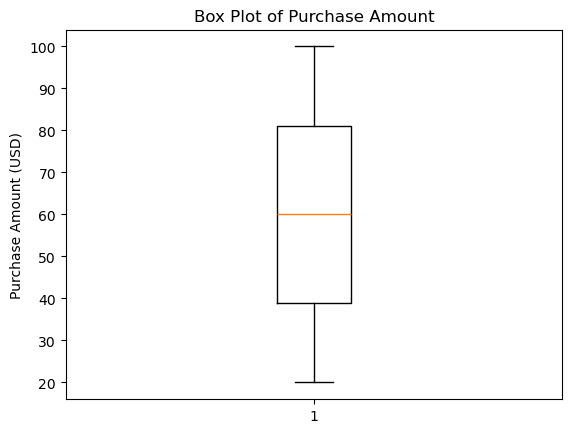

In [41]:
# Make sure column name is correct
purchase = df["Purchase Amount (USD)"]

# Convert to numeric (in case it is object type)
purchase = pd.to_numeric(purchase, errors='coerce')

# Remove missing values
purchase = purchase.dropna()

plt.figure()
plt.boxplot(purchase)
plt.title("Box Plot of Purchase Amount")
plt.ylabel("Purchase Amount (USD)")
plt.show()

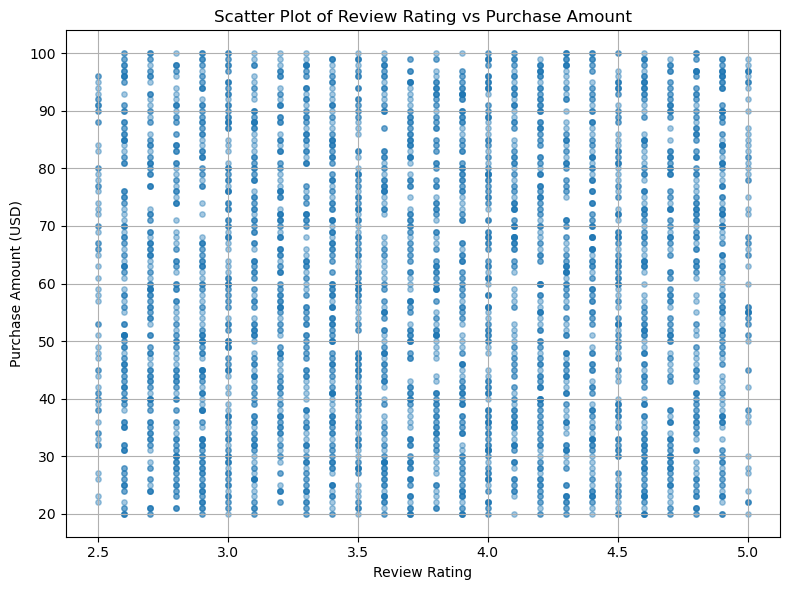

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Review Rating"],
    df["Purchase Amount (USD)"],
    alpha=0.4,          # makes points transparent
    s=15                # smaller point size
)

plt.xlabel("Review Rating")
plt.ylabel("Purchase Amount (USD)")
plt.title("Scatter Plot of Review Rating vs Purchase Amount")

plt.grid(True)
plt.tight_layout()
plt.show()

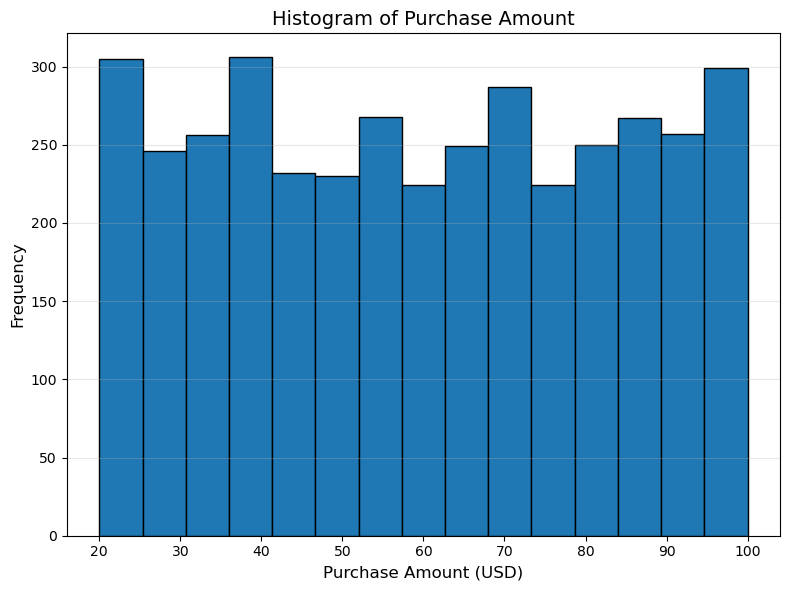

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    df["Purchase Amount (USD)"],
    bins=15,           # control number of bars
    edgecolor="black"  # separate bars clearly
)

plt.xlabel("Purchase Amount (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of Purchase Amount", fontsize=14)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

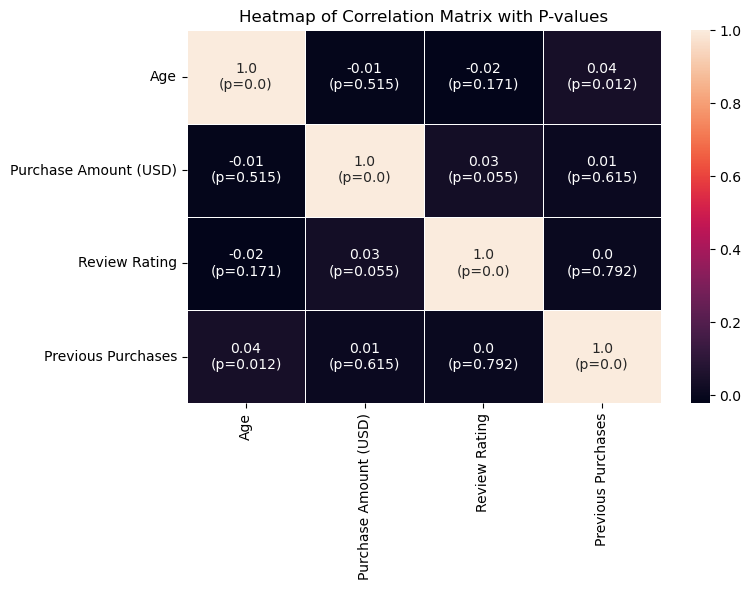

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Remove Customer ID if exists
if "Customer ID" in df.columns:
    df = df.drop(columns=["Customer ID"])

plt.figure(figsize=(8,6))

# Select numeric columns only
correlation = df.corr(numeric_only=True)

# Create empty matrix for p-values
p_values = pd.DataFrame(np.zeros_like(correlation), columns=correlation.columns, index=correlation.index)

# Calculate p-values
for row in correlation.columns:
    for col in correlation.columns:
        corr, p = pearsonr(df[row], df[col])
        p_values.loc[row, col] = p

# Combine correlation and p-value text
annot_matrix = correlation.round(2).astype(str) + "\n(p=" + p_values.round(3).astype(str) + ")"

sns.heatmap(
    correlation,
    annot=annot_matrix,
    fmt="",
    linewidths=0.5
)

plt.title("Heatmap of Correlation Matrix with P-values")
plt.tight_layout()
plt.show()

In [45]:
print(df.isnull().sum())

Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


In [46]:
print(df.duplicated().sum())

0


In [47]:
print(df.dtypes)

Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [48]:
print(df.describe())

               Age  Purchase Amount (USD)  Review Rating  Previous Purchases
count  3900.000000            3900.000000    3900.000000         3900.000000
mean     44.068462              59.764359       3.749949           25.351538
std      15.207589              23.685392       0.716223           14.447125
min      18.000000              20.000000       2.500000            1.000000
25%      31.000000              39.000000       3.100000           13.000000
50%      44.000000              60.000000       3.700000           25.000000
75%      57.000000              81.000000       4.400000           38.000000
max      70.000000             100.000000       5.000000           50.000000


In [49]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation between Age and Purchase Amount
pearson_corr, pearson_p = pearsonr(df["Age"], df["Purchase Amount (USD)"])

# Spearman correlation between Age and Purchase Amount
spearman_corr, spearman_p = spearmanr(df["Age"], df["Purchase Amount (USD)"])

print("Pearson Correlation:", pearson_corr)
print("Pearson p-value:", pearson_p)

print("Spearman Correlation:", spearman_corr)
print("Spearman p-value:", spearman_p)

Pearson Correlation: -0.010423647378686528
Pearson p-value: 0.5151978241224925
Spearman Correlation: -0.010444519559151589
Spearman p-value: 0.514356833416039


In [50]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df["Gender"], df["Category"])

# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 0.5984208314833445
p-value: 0.8967937925861854
Degrees of freedom: 3


In [51]:
from scipy.stats import ttest_1samp

# assume the population mean from the whole dataset
population_mean = df["Purchase Amount (USD)"].mean()

# perform one-sample t-test using the random sample
t_stat, p_value = ttest_1samp(random_sample["Purchase Amount (USD)"], population_mean)

print("Population Mean:", population_mean)
print("Sample Mean:", random_sample["Purchase Amount (USD)"].mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

Population Mean: 59.76435897435898
Sample Mean: 58.36
T-statistic: -0.7287726810739451
P-value: 0.4672846340691196
